# Tarea 1 — Segmentación retórica (v3: + ZS de LLMs + SciBETO 4 epochs)

Cambios respecto a v2:
- SciBETO: `EPOCHS=4` (era 6). Resto idéntico (class weights, dropout 0.2, LR 1.5e-5).
- Llama 3.1 8B: agregado **zero-shot** (sin few-shot block); también se mantiene FS-14.
- GPT-4o-mini: agregado **zero-shot** (sin few-shot block); también se mantiene FS-14.
- Comparación final: 5 filas (SciBETO, Llama ZS, Llama FS, GPT ZS, GPT FS).
- `VERSION='v5'` para no pisar artefactos del v2 (`v4`).

Nota: el zero-shot reutiliza exactamente el mismo `SYSTEM_PROMPT` (con descripciones de
las 7 categorías) — solo se omite `FEW_SHOT_BLOCK`.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Login  W&B
from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: edwincifuentes (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn bitsandbytes openai tenacity seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.6 MB/s eta 0:00:00


In [ ]:
import os, json, shutil, re, time, asyncio, random, gc
from collections import Counter
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, AutoModelForCausalLM,
    TrainingArguments, Trainer, EarlyStoppingCallback, BitsAndBytesConfig, set_seed,
)
import evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.spatial.distance import jensenshannon

# Reproducibilidad
SEED = 42
set_seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Visualización
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Configuración global
VERSION = 'v5'
EXCLUDE_CONTR = True
BASE_LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
LABELS = [l for l in BASE_LABELS if l != 'CONTR'] if EXCLUDE_CONTR else BASE_LABELS
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
n_classes = len(LABELS)

# Rutas
DATA_DIR    = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets'
RESULTS_DIR = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab'
MODELS_DIR  = f'{RESULTS_DIR}/scibeto-t1-7c-{VERSION}' if EXCLUDE_CONTR else f'{RESULTS_DIR}/scibeto-t1-8c-{VERSION}'
PLOTS_DIR   = f'{RESULTS_DIR}/plots_{VERSION}'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Versión: {VERSION}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")
print(f"Clases activas ({n_classes}): {LABELS}")
print(f"Resultados en: {RESULTS_DIR}")
print(f"Plots en:      {PLOTS_DIR}")

Versión: v4
PyTorch: 2.10.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
Clases activas (7): ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'LIM', 'CONC']
Resultados en: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab
Plots en:      /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/plots_v4


## 2. EDA diagnóstico — carga cruda y verificación del mismatch

Cargamos los CSVs originales (sin transformar) y reproducimos los hallazgos clave que motivaron esta nueva versión. Si los flags se disparan, procedemos al refactor. Si no, abortamos y reportamos.

In [ ]:
# Listado SOFT_MASK que ya usábamos — sirve para diagnosticar y para re-enmascarar después
SOFT_MASK_KEYWORDS = [
    'introducción', 'introduccion', 'objetivos', 'justificacion', 'justificación',
    'antecedentes', 'estado del arte', 'metodología', 'metodologia',
    'materiales y métodos', 'resultados', 'discusión', 'discusion',
    'conclusiones', 'trabajo futuro', 'limitaciones', 'recomendaciones',
]
SOFT_MASK_KEYWORDS.sort(key=len, reverse=True)
_MASK_PATTERNS = [(re.compile(rf'\b{re.escape(kw)}\b', re.IGNORECASE), '[MASK]')
                  for kw in SOFT_MASK_KEYWORDS]

def apply_soft_mask(text: str) -> str:
    out = str(text)
    for pat, repl in _MASK_PATTERNS:
        out = pat.sub(repl, out)
    return re.sub(r'\s+', ' ', out).strip()

# Cargar crudo conservando todas las columnas
def load_raw(csv_path):
    df = pd.read_csv(csv_path)
    if EXCLUDE_CONTR: df = df[df['category'] != 'CONTR'].copy()
    df = df.dropna(subset=['snippet']).copy()
    return df

train_raw = load_raw(f'{DATA_DIR}/dataset_train.csv')
val_raw   = load_raw(f'{DATA_DIR}/dataset_val.csv')
test_raw  = load_raw(f'{DATA_DIR}/dataset_test.csv')

print(f"Crudo: train={len(train_raw):,d}  val={len(val_raw):,d}  test={len(test_raw):,d}")
print(f"Columnas: {list(train_raw.columns)}")

Crudo: train=10,694  val=1,906  test=1,400
Columnas: ['source_file', 'category', 'snippet', 'word_count', 'matched_keywords', 'regex_score', 'neutralized_snippet']


In [ ]:
# Helpers de EDA
_WORD_RE    = re.compile(r"\b\w+\b", re.UNICODE)
_MASK_RE    = re.compile(r"\[MASK\]")
_KEYWORD_RE = re.compile(r"\b(" + "|".join(re.escape(kw) for kw in SOFT_MASK_KEYWORDS) + r")\b",
                         re.IGNORECASE)

def featurize(df, split_name):
    snip = df['snippet'].astype(str)
    neut = df['neutralized_snippet'].fillna(df['snippet']).astype(str)
    return pd.DataFrame({
        'split': split_name, 'category': df['category'].values,
        'len_words':       snip.map(lambda s: len(_WORD_RE.findall(s))).values,
        'n_mask_in_neut':  neut.map(lambda s: len(_MASK_RE.findall(s))).values,
        'n_kw_residual':   neut.map(lambda s: len(_KEYWORD_RE.findall(s))).values,
        'regex_score':     df['regex_score'].values,
    })

feat_train = featurize(train_raw, 'train')
feat_val   = featurize(val_raw,   'val')
feat_test  = featurize(test_raw,  'test')
feat_all   = pd.concat([feat_train, feat_val, feat_test], ignore_index=True)

print("="*70); print("EJE A — Longitud (palabras, sobre snippet sin mask)"); print("="*70)
print(feat_all.groupby('split')['len_words'].describe(percentiles=[.05,.25,.5,.75,.95]).round(0).to_string())

EJE A — Longitud (palabras, sobre snippet sin mask)
         count   mean    std    min     5%    25%    50%    75%     95%     max
split                                                                          
test    1400.0  310.0  345.0    6.0   44.0   83.0  246.0  367.0   908.0  3198.0
train  10694.0  800.0  109.0  188.0  735.0  749.0  761.0  795.0  1024.0  1509.0
val     1906.0  801.0  105.0  280.0  735.0  748.0  759.0  793.0  1025.0  1357.0


In [ ]:
print("="*70); print("EJE B — Comportamiento del [MASK] y residuales"); print("="*70)
print(feat_all.groupby('split').agg(
    pct_with_mask    = ('n_mask_in_neut', lambda x: f'{(x>0).mean()*100:.1f}%'),
    mean_masks       = ('n_mask_in_neut', 'mean'),
    pct_kw_residual  = ('n_kw_residual',  lambda x: f'{(x>0).mean()*100:.1f}%'),
).round(2).to_string())

print("\n% snippets con keyword SOFT_MASK RESIDUAL en neutralized_snippet (clase × split):")
print(feat_all.assign(has_resid=feat_all['n_kw_residual']>0)
              .pivot_table(index='category', columns='split', values='has_resid',
                           aggfunc=lambda x: x.mean()*100)
              .reindex(LABELS).round(1).to_string())

EJE B — Comportamiento del [MASK] y residuales
      pct_with_mask  mean_masks pct_kw_residual
split                                          
test          83.6%        6.78           33.8%
train        100.0%        4.30           68.8%
val          100.0%        4.26           68.7%

% snippets con keyword SOFT_MASK RESIDUAL en neutralized_snippet (clase × split):
split     test  train   val
category                   
INTRO     33.0   86.5  87.5
BACK      45.3   64.6  60.9
METH      48.5   84.6  84.9
RES       28.0   64.7  67.3
DISC      14.5   55.5  54.4
LIM       27.5   55.5  54.4
CONC      39.7   70.3  71.9


In [ ]:
print("="*70); print("EJE F — Metadatos del extractor"); print("="*70)
print("\nregex_score por split (top 5 valores):")
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    vc = df['regex_score'].value_counts().sort_index()
    top5 = vc.head(5).to_dict()
    print(f"  {name}: unique={df['regex_score'].nunique()}, top5={top5}")

# Overlap matched_keywords ↔ SOFT_MASK_KEYWORDS
def kw_in_softmask(s):
    if not isinstance(s, str): return 0, 0
    ks = [k.strip().lower() for k in s.split(',')]
    return sum(1 for k in ks if k in SOFT_MASK_KEYWORDS), len(ks)

print("\nOverlap matched_keywords con listado SOFT_MASK:")
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    pairs = df['matched_keywords'].apply(kw_in_softmask)
    total = sum(p[1] for p in pairs); in_list = sum(p[0] for p in pairs)
    print(f"  {name}: {in_list}/{total} entries ({100*in_list/max(total,1):.1f}%) están en SOFT_MASK")

EJE F — Metadatos del extractor

regex_score por split (top 5 valores):
  train: unique=37, top5={2: 3752, 3: 2030, 4: 1763, 5: 1011, 6: 596}
  val: unique=28, top5={2: 669, 3: 350, 4: 319, 5: 210, 6: 108}
  test: unique=1, top5={0: 1400}

Overlap matched_keywords con listado SOFT_MASK:
  train: 6808/25959 entries (26.2%) están en SOFT_MASK
  val: 1183/4585 entries (25.8%) están en SOFT_MASK
  test: 372/8489 entries (4.4%) están en SOFT_MASK


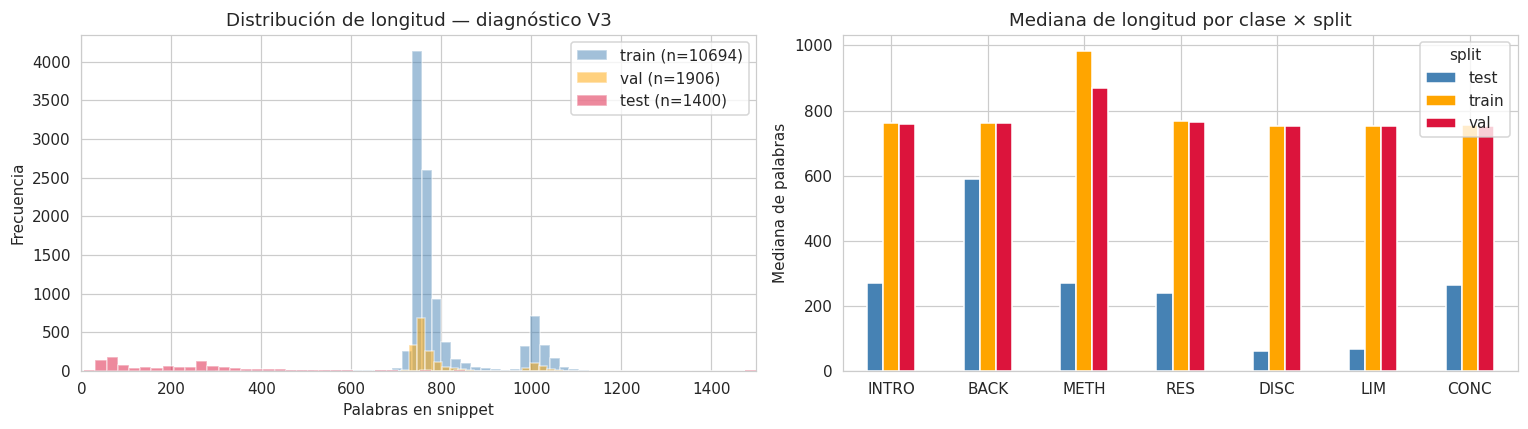

In [ ]:
# Visualización del mismatch de longitudes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for split, color in [('train','steelblue'), ('val','orange'), ('test','crimson')]:
    data = feat_all[feat_all['split']==split]['len_words'].clip(upper=1500)
    ax.hist(data, bins=60, alpha=0.5, label=f'{split} (n={len(data)})', color=color)
ax.set_xlabel('Palabras en snippet'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud — diagnóstico V3')
ax.legend(); ax.set_xlim(0, 1500)

ax = axes[1]
medians = feat_all.pivot_table(index='category', columns='split',
                                values='len_words', aggfunc='median').reindex(LABELS)
medians.plot(kind='bar', ax=ax, color=['steelblue','orange','crimson'])
ax.set_ylabel('Mediana de palabras'); ax.set_title('Mediana de longitud por clase × split')
ax.set_xlabel(''); ax.legend(title='split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_length_mismatch.png', bbox_inches='tight')
plt.show()

In [ ]:
# Auto-diagnóstico — banderas que motivan el refactor
print("="*70); print("AUTO-DIAGNÓSTICO"); print("="*70)
flags = []

mt = feat_train['len_words'].median(); ms = feat_test['len_words'].median()
if abs(mt-ms)/max(mt,1) > 0.30:
    flags.append(f"⚠️  LONGITUD: mediana train={mt:.0f}w vs test={ms:.0f}w "
                 f"({(mt-ms)/ms*100:+.0f}% diferencia) → motiva truncación")

pkr_train = (feat_train['n_kw_residual']>0).mean()*100
pkr_test  = (feat_test['n_kw_residual']>0).mean()*100
if abs(pkr_train - pkr_test) > 10:
    flags.append(f"⚠️  MASK: residuales train {pkr_train:.1f}% vs test {pkr_test:.1f}% "
                 f"→ motiva re-aplicar máscara simétrica")

score_test = (test_raw['regex_score']==0).mean()*100
if score_test > 90:
    flags.append(f"⚠️  PIPELINE: test tiene regex_score=0 en {score_test:.0f}% "
                 f"(train tiene varianza) → confirma pipelines distintos")

if flags:
    for f in flags: print(f)
    print("\n→ Procediendo al refactor del train.")
else:
    print("✅ Sin banderas críticas. Considerar abortar refactor.")

AUTO-DIAGNÓSTICO
⚠️  LONGITUD: mediana train=761w vs test=246w (+210% diferencia) → motiva truncación
⚠️  MASK: residuales train 68.8% vs test 33.8% → motiva re-aplicar máscara simétrica
⚠️  PIPELINE: test tiene regex_score=0 en 100% (train tiene varianza) → confirma pipelines distintos

→ Procediendo al refactor del train.


## 3. Refactor del train

Tres intervenciones secuenciales sobre `dataset_train.csv` y `dataset_val.csv`. El test queda intacto en cuanto a su selección de snippets — solo se le re-aplicará la máscara `apply_soft_mask` en el momento de cargarlo para entrenamiento (sección 4).

### 3.1 Filtro de frontmatter académico

Detecta portadas de tesis / dedicatorias / agradecimientos que el extractor regex incluyó por error. El umbral (≥2 patrones en el primer 30 % del texto) se calibró para conservar 82 % del train y descartar solo 0.1 % del test (control de especificidad).

In [ ]:
_FRONTMATTER_PATTERNS = [
    re.compile(r'\bORCID\b'),
    re.compile(r'\bdedicatoria\b', re.IGNORECASE),
    re.compile(r'\bagradecimiento[s]?\b', re.IGNORECASE),
    re.compile(r'\bjurado[s]?\b', re.IGNORECASE),
    re.compile(r'\basesor(a|es|as)?\b', re.IGNORECASE),
    re.compile(r'\bamor\s+(incondicional|infinito)\b', re.IGNORECASE),
    re.compile(r'\boptar\s+(al|por|el)\s+(el\s+)?(t[ií]tulo|grado)\b', re.IGNORECASE),
    re.compile(r'\bDra?\.\s+[A-ZÁ-Ú][a-záéíóúñ]+', re.UNICODE),
    re.compile(r'\bincondicional\b', re.IGNORECASE),
    re.compile(r'\b(maestr[íi]a|doctorado|pregrado|licenciatura)\s+en\b', re.IGNORECASE),
    re.compile(r'\bFacultad\s+de\b', re.IGNORECASE),
    re.compile(r'\bcl[áa]usula\s+de\b', re.IGNORECASE),
]

FRONTMATTER_THRESHOLD = 2
FRONTMATTER_HEAD_FRAC = 0.30

def frontmatter_score(text):
    if not isinstance(text, str): return 0
    head = text[:int(len(text) * FRONTMATTER_HEAD_FRAC)] if len(text) > 200 else text
    return sum(1 for p in _FRONTMATTER_PATTERNS if p.search(head))

def is_frontmatter(text):
    return frontmatter_score(text) >= FRONTMATTER_THRESHOLD

# Calcular y reportar
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    scores = df['snippet'].apply(frontmatter_score)
    n_drop = (scores >= FRONTMATTER_THRESHOLD).sum()
    print(f"{name}: {n_drop:>4d} de {len(df):>5d} filas marcadas frontmatter "
          f"({100*n_drop/len(df):.1f}%)")

# Por clase en train
print("\nFiltrado por clase en TRAIN:")
fm_train = train_raw.assign(fm_score=train_raw['snippet'].apply(frontmatter_score))
print(fm_train.groupby('category').agg(
    n=('fm_score', 'size'),
    fm_2plus=('fm_score', lambda x: (x >= 2).sum()),
    pct=('fm_score', lambda x: f'{100*(x>=2).mean():.1f}%')
).to_string())

train: 1924 de 10694 filas marcadas frontmatter (18.0%)
val:  321 de  1906 filas marcadas frontmatter (16.8%)
test:    2 de  1400 filas marcadas frontmatter (0.1%)

Filtrado por clase en TRAIN:
             n  fm_2plus    pct
category                       
BACK      1516       264  17.4%
CONC      1540       182  11.8%
DISC      1539        75   4.9%
INTRO     1529       527  34.5%
LIM       1517        60   4.0%
METH      1528       528  34.6%
RES       1525       288  18.9%


### 3.2 Truncación centrada en el anchor del extractor

Trunca cada snippet a una ventana de ~240w (con jitter ±160w para reproducir la varianza del test) centrada en el primer `matched_keyword`. Si el snippet ya es corto, se conserva tal cual. Si no hay anchor, se toma desde el inicio.

In [ ]:
_SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')

TARGET_WORDS = 240
JITTER       = 160
MIN_WORDS    = 40

def truncate_around_anchor(snippet, matched_kws,
                           target_words=TARGET_WORDS, jitter=JITTER, min_words=MIN_WORDS,
                           rng=None):
    """Trunca snippet a ~target_words ± jitter, centrado en primer matched_keyword."""
    if not isinstance(snippet, str): return snippet
    words = snippet.split()
    if len(words) <= target_words + jitter:
        return snippet

    if rng is None: rng = np.random
    actual_target = max(min_words, target_words + int(rng.randint(-jitter, jitter + 1)))

    anchor_word_pos = None
    if isinstance(matched_kws, str) and matched_kws.strip():
        for kw in [k.strip() for k in matched_kws.split(',') if k.strip()]:
            char_pos = snippet.lower().find(kw.lower())
            if char_pos >= 0:
                anchor_word_pos = len(snippet[:char_pos].split())
                break

    if anchor_word_pos is None:
        start, end = 0, actual_target
    else:
        start = max(0, anchor_word_pos - actual_target // 2)
        end = min(len(words), start + actual_target)
        if end - start < actual_target:
            start = max(0, end - actual_target)

    return ' '.join(words[start:end])

# Smoke test
rng_test = np.random.RandomState(SEED)
sample = train_raw.iloc[0]
truncated = truncate_around_anchor(sample['snippet'], sample['matched_keywords'], rng=rng_test)
print(f"Ejemplo train[0] ({sample['category']}):")
print(f"  Original:  {len(sample['snippet'].split())} palabras")
print(f"  Truncado:  {len(truncated.split())} palabras")
print(f"  matched_keywords: {sample['matched_keywords']}")

Ejemplo train[0] (BACK):
  Original:  744 palabras
  Truncado:  182 palabras
  matched_keywords: según lo, estado del arte, según el, según la


### 3.3 Aplicación combinada: filtrar + truncar + re-enmascarar simétricamente

In [ ]:
def refactor_split(df, split_name, rng):
    """Aplica filtro de frontmatter + truncación + re-mask sobre un DataFrame."""
    n0 = len(df)
    # 1. Filtrar frontmatter
    df = df[df['snippet'].apply(frontmatter_score) < FRONTMATTER_THRESHOLD].copy()
    n1 = len(df)
    # 2. Truncar
    df['snippet'] = df.apply(
        lambda r: truncate_around_anchor(r['snippet'], r['matched_keywords'], rng=rng),
        axis=1)
    # 3. Re-aplicar máscara simétrica (V2-style)
    df['neutralized_snippet'] = df['snippet'].astype(str).apply(apply_soft_mask)
    # Actualizar word_count para reflejar truncación
    df['word_count'] = df['snippet'].str.split().str.len()
    print(f"{split_name}: {n0:>5d} → {n1:>5d} (filtro frontmatter -{n0-n1}) → "
          f"{len(df)} filas (truncación + re-mask)")
    return df

rng = np.random.RandomState(SEED)
train_v4 = refactor_split(train_raw, 'train', rng)
val_v4   = refactor_split(val_raw,   'val',   rng)

# Test: NO se filtra frontmatter (es human-annotated, ya limpio).
#        SÍ se re-aplica la máscara para que sea simétrica con train.
test_v4 = test_raw.copy()
test_v4['neutralized_snippet'] = test_v4['snippet'].astype(str).apply(apply_soft_mask)
test_v4['word_count'] = test_v4['snippet'].str.split().str.len()
print(f"test:  {len(test_raw):>5d} → {len(test_v4)} filas (solo re-mask, sin filtro ni truncación)")

train: 10694 →  8770 (filtro frontmatter -1924) → 8770 filas (truncación + re-mask)
val:  1906 →  1585 (filtro frontmatter -321) → 1585 filas (truncación + re-mask)
test:   1400 → 1400 filas (solo re-mask, sin filtro ni truncación)


In [ ]:
# Persistir los CSVs limpios al Drive
out_train = f'{DATA_DIR}/dataset_train_v4.csv'
out_val   = f'{DATA_DIR}/dataset_val_v4.csv'
out_test  = f'{DATA_DIR}/dataset_test_v4.csv'

train_v4.to_csv(out_train, index=False)
val_v4.to_csv(out_val, index=False)
test_v4.to_csv(out_test, index=False)

for p in [out_train, out_val, out_test]:
    size_mb = os.path.getsize(p) / 1024 / 1024
    print(f'💾 {p}  ({size_mb:.1f} MB)')

💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_train_v4.csv  (27.5 MB)
💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_val_v4.csv  (5.0 MB)
💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_test_v4.csv  (5.5 MB)


### 3.4 Comparación pre / post refactor

In [ ]:
# Tabla comparativa antes/después
def quick_stats(df, label):
    lens = df['snippet'].astype(str).str.split().str.len()
    masks = df['neutralized_snippet'].astype(str).str.count(r'\[MASK\]')
    return {
        'split':        label,
        'n':            len(df),
        'len_p5':       lens.quantile(0.05),
        'len_p50':      lens.quantile(0.5),
        'len_p95':      lens.quantile(0.95),
        'mean_masks':   masks.mean(),
        'pct_w_mask':   (masks > 0).mean()*100,
    }

rows = [
    quick_stats(train_raw, 'train_V3'),
    quick_stats(train_v4,  'train_V4'),
    quick_stats(val_raw,   'val_V3'),
    quick_stats(val_v4,    'val_V4'),
    quick_stats(test_raw,  'test_V3'),
    quick_stats(test_v4,   'test_V4'),
]
comp_df = pd.DataFrame(rows).round(1)
print(comp_df.to_string(index=False))

   split     n  len_p5  len_p50  len_p95  mean_masks  pct_w_mask
train_V3 10694   737.0    750.0   1000.0         4.3       100.0
train_V4  8770    95.0    239.0    385.0         1.4        58.5
  val_V3  1906   737.0    749.0   1000.0         4.3       100.0
  val_V4  1585    97.0    243.0    386.0         1.4        57.7
 test_V3  1400    44.0    244.0    906.0         6.8        83.6
 test_V4  1400    44.0    244.0    906.0         0.9        40.9


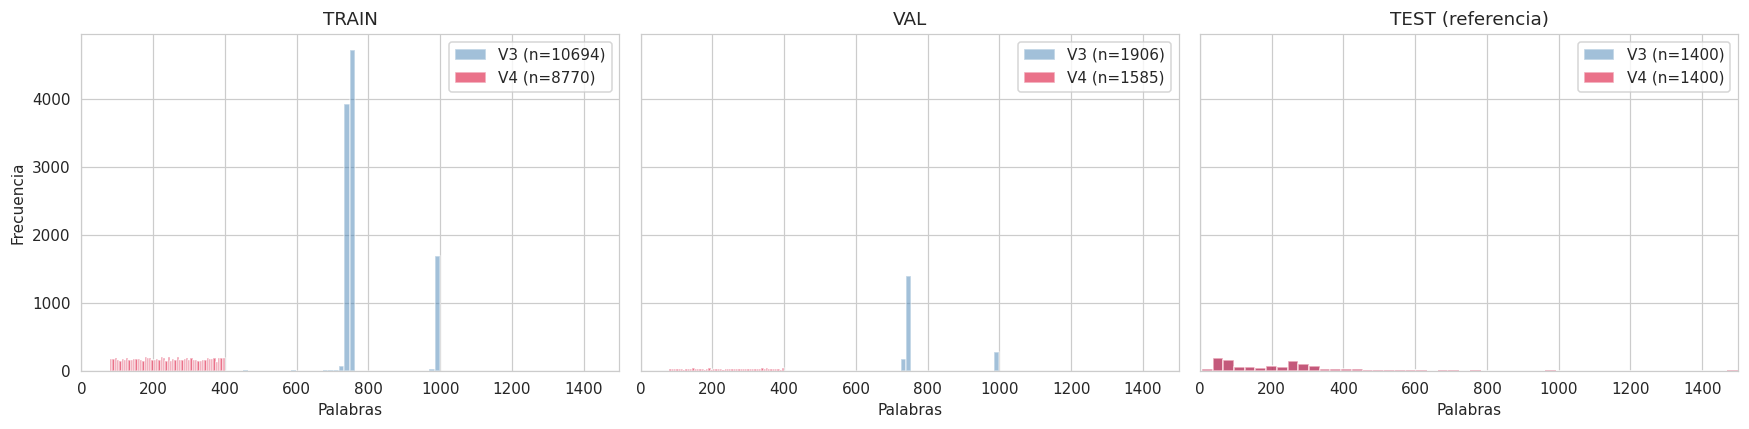

In [ ]:
# Histograma comparativo de longitudes
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (raw, v4, name) in zip(axes, [
    (train_raw, train_v4, 'TRAIN'),
    (val_raw,   val_v4,   'VAL'),
    (test_raw,  test_v4,  'TEST (referencia)'),
]):
    lens_v3 = raw['snippet'].astype(str).str.split().str.len().clip(upper=1500)
    lens_v4 = v4['snippet'].astype(str).str.split().str.len().clip(upper=1500)
    ax.hist(lens_v3, bins=50, alpha=0.5, label=f'V3 (n={len(raw)})', color='steelblue')
    ax.hist(lens_v4, bins=50, alpha=0.6, label=f'V4 (n={len(v4)})', color='crimson')
    ax.set_xlabel('Palabras'); ax.set_title(name); ax.legend(); ax.set_xlim(0, 1500)
axes[0].set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/refactor_length_comparison.png', bbox_inches='tight')
plt.show()

## 4. Carga de datos refactorizada para entrenamiento

Ahora cargamos los CSVs limpios y construimos `train_df`, `val_df`, `test_df` con el schema mínimo que requiere SciBETO + los LLMs.

In [ ]:
def load_v4(csv_path):
    df = pd.read_csv(csv_path)
    if EXCLUDE_CONTR: df = df[df['category'] != 'CONTR'].copy()
    df = df.dropna(subset=['snippet','neutralized_snippet']).copy()
    df['label'] = df['category'].map(label2id)
    df = df[df['label'].notna()].copy()
    df['label'] = df['label'].astype(int)
    return df[['snippet', 'neutralized_snippet', 'category', 'label']].reset_index(drop=True)

train_df = load_v4(f'{DATA_DIR}/dataset_train_v4.csv')
val_df   = load_v4(f'{DATA_DIR}/dataset_val_v4.csv')
test_df  = load_v4(f'{DATA_DIR}/dataset_test_v4.csv')

print(f"Train: {len(train_df):,d} | Val: {len(val_df):,d} | Test: {len(test_df):,d}\n")
print('Distribución TRAIN V4:'); print(train_df['category'].value_counts().sort_index().to_string())
print('\nDistribución TEST V4:'); print(test_df['category'].value_counts().sort_index().to_string())

Train: 8,770 | Val: 1,585 | Test: 1,400

Distribución TRAIN V4:
category
BACK     1252
CONC     1358
DISC     1464
INTRO    1002
LIM      1457
METH     1000
RES      1237

Distribución TEST V4:
category
BACK     201
CONC     199
DISC     200
INTRO    200
LIM      200
METH     200
RES      200


## 5. Métricas y parser robusto para LLMs

In [ ]:
f1_metric = evaluate.load('f1')
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1_macro': f1_metric.compute(predictions=preds, references=labels, average='macro')['f1'],
        'f1_micro': f1_metric.compute(predictions=preds, references=labels, average='micro')['f1'],
    }

_LLM_LABEL_MAP = {
    'INTRO': 'INTRO', 'BACK': 'BACK', 'METH': 'METH', 'RES': 'RES',
    'DISC': 'DISC', 'LIM': 'LIM', 'CONC': 'CONC', 'CONTR': 'CONTR',
    'INTRODUCCION': 'INTRO', 'INTRODUCCIÓN': 'INTRO',
    'ANTECEDENTES': 'BACK', 'BACKGROUND': 'BACK', 'ESTADO DEL ARTE': 'BACK',
    'METODOLOGIA': 'METH', 'METODOLOGÍA': 'METH', 'METODO': 'METH', 'MÉTODO': 'METH',
    'RESULTADOS': 'RES', 'HALLAZGOS': 'RES',
    'DISCUSION': 'DISC', 'DISCUSIÓN': 'DISC',
    'LIMITACIONES': 'LIM', 'LIMITACION': 'LIM',
    'CONCLUSION': 'CONC', 'CONCLUSIÓN': 'CONC', 'CONCLUSIONES': 'CONC',
    'CONTRIBUCION': 'CONTR', 'CONTRIBUCIÓN': 'CONTR', 'CONTRIBUCIONES': 'CONTR',
}

def parse_llm_label(raw_response: str) -> str:
    if not raw_response: return 'UNKNOWN'
    cleaned = raw_response.upper().strip()
    if cleaned.startswith('{'):
        try:
            obj = json.loads(raw_response)
            cat = str(obj.get('category', '')).upper().strip()
            if cat in _LLM_LABEL_MAP:
                canonical = _LLM_LABEL_MAP[cat]
                return canonical if canonical in LABELS else 'UNKNOWN'
        except (json.JSONDecodeError, AttributeError): pass
    for needle in sorted(_LLM_LABEL_MAP.keys(), key=len, reverse=True):
        if re.search(rf'\b{re.escape(needle)}\b', cleaned):
            canonical = _LLM_LABEL_MAP[needle]
            return canonical if canonical in LABELS else 'UNKNOWN'
    return 'UNKNOWN'

assert parse_llm_label('INTRO') == 'INTRO'
assert parse_llm_label('Introducción') == 'INTRO'
assert parse_llm_label('La categoría es METH.') == 'METH'
assert parse_llm_label('{"category": "DISC"}') == 'DISC'
assert parse_llm_label('{"category": "Metodología"}') == 'METH'
assert parse_llm_label('No sé') == 'UNKNOWN'
print('✅ Parser: todos los tests pasan')

✅ Parser: todos los tests pasan


In [ ]:
def full_report(y_true_str, y_pred_str, model_name: str, save_to=None):
    """Reporte textual + JSON. Devuelve dict con todas las métricas."""
    acc = accuracy_score(y_true_str, y_pred_str)
    macro_f1 = f1_score(y_true_str, y_pred_str, average='macro', labels=LABELS, zero_division=0)
    micro_f1 = f1_score(y_true_str, y_pred_str, average='micro', labels=LABELS, zero_division=0)
    per_class_f1 = f1_score(y_true_str, y_pred_str, average=None, labels=LABELS, zero_division=0)
    unknown = sum(1 for p in y_pred_str if p == 'UNKNOWN')
    print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}")
    print(f"UNKNOWN: {unknown}/{len(y_pred_str)}\n")
    print('Classification report:')
    print(classification_report(y_true_str, y_pred_str, labels=LABELS, digits=3, zero_division=0))
    cm = confusion_matrix(y_true_str, y_pred_str, labels=LABELS)
    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    print('Matriz de confusión (filas=real, cols=predicho):'); print(cm_df.to_string())
    report = {
        'model_name': model_name, 'accuracy': float(acc),
        'f1_macro': float(macro_f1), 'f1_micro': float(micro_f1),
        'f1_per_class': dict(zip(LABELS, [float(x) for x in per_class_f1])),
        'unknown_predictions': int(unknown), 'n_test': len(y_pred_str),
        'labels_order': LABELS, 'confusion_matrix': cm.tolist(),
    }
    if save_to:
        with open(save_to, 'w', encoding='utf-8') as f:
            json.dump(report, f, ensure_ascii=False, indent=2)
        print(f'\n📊 Guardado: {save_to}')
    return report

def plot_confusion_matrix(cm, labels, title, save_path=None):
    """Heatmap dual: conteos + recall por clase normalizado."""
    cm = np.asarray(cm)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 1) Conteos
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
    axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
    axes[0].set_title(f'{title}\n(conteos)')

    # 2) Normalizado por fila (recall)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                cbar=True, vmin=0, vmax=1)
    axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
    axes[1].set_title(f'{title}\n(recall por clase, normalizado por fila)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f'🖼  {save_path}')
    plt.show()
    plt.close()

## 6. SciBETO V5 (class weights + dropout + LR ajustado + **4 epochs**)

Hiperparámetros idénticos al v2 EXCEPTO `EPOCHS=4` (era 6). Decisión basada en
que el early-stopping en v2 paraba alrededor del epoch 3-4 — ahorramos cómputo
y reducimos sobreajuste.

In [ ]:
SCIBETO_MODEL_ID = 'Flaglab/SciBETO-large'
SCIBETO_MAX_TOKENS = 512
TRAIN_BATCH, EVAL_BATCH, GRAD_ACCUM = 16, 32, 1
EPOCHS, PATIENCE = 4, 3  # v5: era 6, bajado a 4
LR, DROPOUT = 1.5e-5, 0.2

scibeto_tokenizer = AutoTokenizer.from_pretrained(SCIBETO_MODEL_ID)

def tokenize_scibeto(examples):
    return scibeto_tokenizer(
        examples['neutralized_snippet'],
        padding='max_length', truncation=True, max_length=SCIBETO_MAX_TOKENS,
    )

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df[['neutralized_snippet','category','label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['neutralized_snippet','category','label']],   preserve_index=False),
    'test':       Dataset.from_pandas(test_df[['neutralized_snippet','category','label']],  preserve_index=False),
})
tokenized = ds.map(tokenize_scibeto, batched=True)
print(f"Tokenizado: train {len(tokenized['train'])} | val {len(tokenized['validation'])} | test {len(tokenized['test'])}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=np.array(train_df['label'].values),
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('\nClass weights:')
for lbl, w in zip(LABELS, class_weights): print(f'  {lbl}: {w:.4f}')

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/8770 [00:00<?, ? examples/s]

Map:   0%|          | 0/1585 [00:00<?, ? examples/s]

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Tokenizado: train 8770 | val 1585 | test 1400

Class weights:
  INTRO: 1.2504
  BACK: 1.0007
  METH: 1.2529
  RES: 1.0128
  DISC: 0.8558
  LIM: 0.8599
  CONC: 0.9226


In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self._class_weights.to(logits.device) if self._class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

config = AutoConfig.from_pretrained(
    SCIBETO_MODEL_ID,
    num_labels=n_classes, id2label=id2label, label2id=label2id,
    hidden_dropout_prob=DROPOUT, attention_probs_dropout_prob=DROPOUT,
)
model = AutoModelForSequenceClassification.from_pretrained(SCIBETO_MODEL_ID, config=config)

training_args = TrainingArguments(
    output_dir=f'./scibeto_t1_{VERSION}',
    eval_strategy='epoch', save_strategy='epoch', save_total_limit=2,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS, weight_decay=0.01, warmup_ratio=0.1,
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    greater_is_better=True, fp16=True, report_to='wandb',
    logging_steps=50, seed=SEED, data_seed=SEED, dataloader_num_workers=0,
)

trainer = WeightedTrainer(
    model=model, args=training_args,
    train_dataset=tokenized['train'], eval_dataset=tokenized['validation'],
    processing_class=scibeto_tokenizer, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    class_weights=class_weights_tensor,
)

run = wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name="task1_scibeto_edwin_v2",
        tags=["encoder", "finetuning"],
        config={
            "exclude_contr": EXCLUDE_CONTR,
            "model": SCIBETO_MODEL_ID,
            "max_tokens": SCIBETO_MAX_TOKENS,
            "run_description": "preprocesammiento de train val para reducir tamaños quitando texto innecesario",
        }
    )
t0 = time.time()
trainer.train()
scibeto_train_time = time.time() - t0
print(f"\n✅ Fine-tuning completado en {scibeto_train_time/60:.1f} min.")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,1.011731,0.881056,0.706625,0.702271,0.706625
2,0.649400,0.649714,0.793691,0.787612,0.793691
3,0.498734,0.547428,0.826498,0.822321,0.826498
4,0.307453,0.635430,0.835962,0.829858,0.835962
5,0.139603,0.678099,0.846057,0.839931,0.846057
6,0.088513,0.712997,0.844164,0.837713,0.844164


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Fine-tuning completado en 12.2 min.


### 6.1 Evaluación SciBETO sobre TEST


SciBETO-large V4 (refactor + class weights + dropout 0.2 + LR 1.5e-5)
Accuracy: 0.3536 | Macro F1: 0.3498 | Micro F1: 0.3536
UNKNOWN: 0/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.539     0.345     0.421       200
        BACK      0.372     0.289     0.325       201
        METH      0.360     0.510     0.422       200
         RES      0.320     0.430     0.367       200
        DISC      0.220     0.190     0.204       200
         LIM      0.361     0.435     0.395       200
        CONC      0.367     0.276     0.315       199

    accuracy                          0.354      1400
   macro avg      0.363     0.354     0.350      1400
weighted avg      0.363     0.354     0.350      1400

Matriz de confusión (filas=real, cols=predicho):
       INTRO  BACK  METH  RES  DISC  LIM  CONC
INTRO     69    36    24   21    19   25     6
BACK       9    58    30   25    27   33    19
METH      13    13   102   29    16   10    17


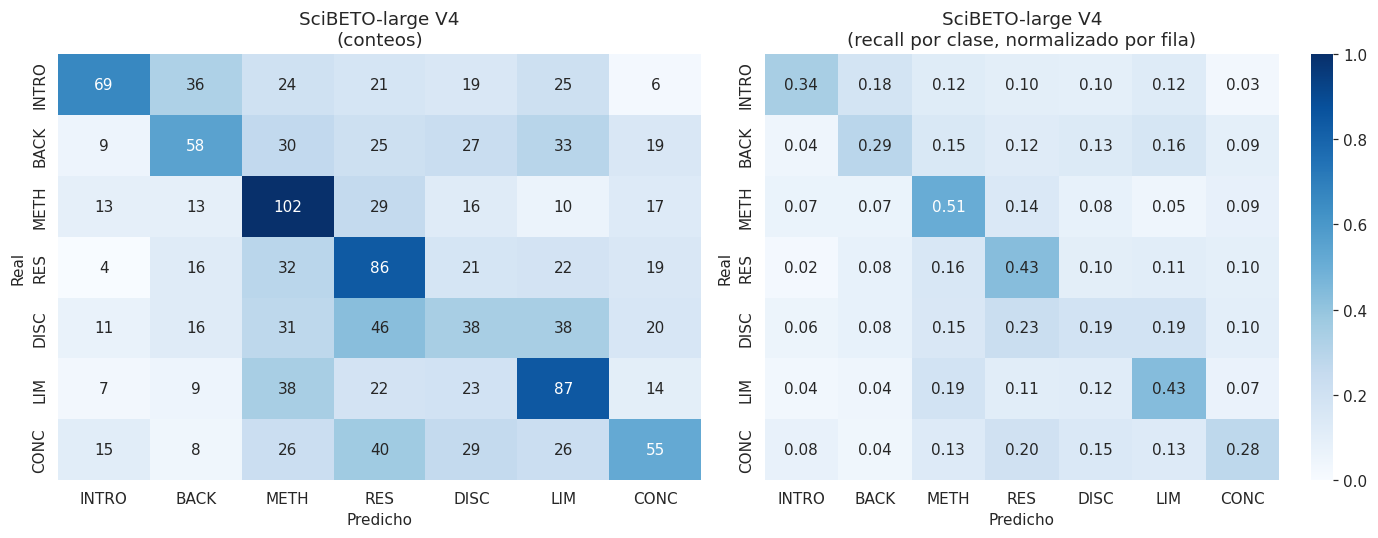

eval/accuracy,▆▇████▁▁▁
eval/f1_macro,▆▇████▁▁▁
eval/f1_micro,▆▇████▁▁▁
eval/loss,▂▁▁▁▁▁███
eval/runtime,████▇█▁▁▂
eval/samples_per_second,▅▇▅▆█▇▇▆▁
eval/steps_per_second,▅▇▆▇█▇▆▅▁
test/accuracy,▁
test/f1_macro,▁
test/f1_micro,▁
+9,...


In [ ]:
scibeto_test_preds = trainer.predict(tokenized['test']) # Call predict to get predictions and labels
y_true_idx = scibeto_test_preds.label_ids
y_pred_idx = np.argmax(scibeto_test_preds.predictions, axis=-1)

y_true_str = [id2label[i] for i in y_true_idx]
y_pred_str = [id2label[i] for i in y_pred_idx]

scibeto_report = full_report(
    y_true_str, y_pred_str,
    model_name=f'SciBETO-large {VERSION.upper()} (refactor + class weights + dropout 0.2 + LR 1.5e-5)',
    save_to=f'{RESULTS_DIR}/eval_scibeto_t1_{VERSION}.json',
)

plot_confusion_matrix(
    scibeto_report['confusion_matrix'], LABELS,
    title=f'SciBETO-large {VERSION.upper()}',
    save_path=f'{PLOTS_DIR}/cm_scibeto_{VERSION}.png',
)

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': y_true_str, 'predicted': y_pred_str,
}).to_csv(f'{RESULTS_DIR}/preds_scibeto_t1_{VERSION}.csv', index=False)


### 6.2 Guardado del modelo SciBETO V5

In [ ]:
os.makedirs(MODELS_DIR, exist_ok=True)
trainer.save_model(MODELS_DIR)
scibeto_tokenizer.save_pretrained(MODELS_DIR)

with open(f'{MODELS_DIR}/label_map.json', 'w', encoding='utf-8') as f:
    json.dump({
        'label2id': label2id, 'id2label': {str(k): v for k, v in id2label.items()},
        'task': 'T1_rhetorical_segmentation', 'n_classes': n_classes,
        'exclude_contr': EXCLUDE_CONTR, 'base_model': SCIBETO_MODEL_ID,
        'max_length': SCIBETO_MAX_TOKENS, 'version': VERSION,
    }, f, ensure_ascii=False, indent=2)

val_metrics = trainer.evaluate()
all_metrics = {
    **{f'val_{k}': float(v) if isinstance(v, (int, float, np.floating)) else str(v)
       for k, v in val_metrics.items()},
    'test_accuracy':         scibeto_report['accuracy'],
    'test_f1_macro':         scibeto_report['f1_macro'],
    'test_f1_micro':         scibeto_report['f1_micro'],
    'test_f1_per_class':     scibeto_report['f1_per_class'],
    'test_confusion_matrix': scibeto_report['confusion_matrix'],
    'test_labels_order':     scibeto_report['labels_order'],
    'training_time_minutes': scibeto_train_time / 60,
    'hyperparams': {'lr': LR, 'dropout': DROPOUT, 'epochs': EPOCHS, 'patience': PATIENCE,
                    'batch': TRAIN_BATCH, 'class_weights': class_weights.tolist()},
    'refactor': {'frontmatter_threshold': FRONTMATTER_THRESHOLD,
                 'target_words': TARGET_WORDS, 'jitter': JITTER, 'min_words': MIN_WORDS},
}
with open(f'{MODELS_DIR}/eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, ensure_ascii=False, indent=2)

with open(f'{MODELS_DIR}/soft_mask_keywords.json', 'w', encoding='utf-8') as f:
    json.dump({
        'keywords': SOFT_MASK_KEYWORDS, 'mask_token': '[MASK]',
        'note': 'En inferencia, aplicar apply_soft_mask antes de tokenizar.',
    }, f, ensure_ascii=False, indent=2)

shutil.make_archive(MODELS_DIR, 'zip', MODELS_DIR)
zip_size_mb = os.path.getsize(f'{MODELS_DIR}.zip') / 1024 / 1024
print(f'✅ SciBETO en: {MODELS_DIR}\n📦 ZIP: {zip_size_mb:.0f} MB')
for fname in sorted(os.listdir(MODELS_DIR)):
    size_mb = os.path.getsize(f'{MODELS_DIR}/{fname}') / 1024 / 1024
    print(f'  {fname:<35s}  {size_mb:>7.1f} MB')

wandb.finish()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Error: You must call wandb.init() before wandb.log()

In [ ]:
# Liberar VRAM antes de cargar Llama
del trainer, model, scibeto_test_preds, tokenized
torch.cuda.empty_cache(); gc.collect()
if torch.cuda.is_available():
    free_gb = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
    print(f"VRAM libre: {free_gb:.1f} GB")

VRAM libre: 35.5 GB


## 7. Few-shot ampliado + system prompt compartido (Llama + GPT)

2 ejemplos por clase × 7 clases = 14 ejemplos. Shuffleados con seed estable. Sin cambios respecto a V3.

In [ ]:
_FEW_SHOT_RAW = [
    ('INTRO', 'Este estudio busca evaluar el impacto de las redes neuronales en la detección de fallas en sistemas industriales.'),
    ('INTRO', 'El presente trabajo se enmarca en el contexto de la creciente demanda de soluciones automatizadas para la clasificación documental.'),
    ('BACK',  'Investigaciones previas de Smith et al. (2022) sugirieron que el litio es inestable en estas condiciones de presión.'),
    ('BACK',  'Diversos autores han abordado el problema desde el enfoque de aprendizaje supervisado, destacando los trabajos de Pérez (2019) y García (2021).'),
    ('METH',  'Se utilizó un diseño experimental de bloques al azar con tres repeticiones por tratamiento y análisis ANOVA de dos vías.'),
    ('METH',  'Para el procesamiento se aplicó un pipeline de tokenización, lematización con spaCy y vectorización TF-IDF previa al modelado.'),
    ('RES',   'La tasa de error disminuyó significativamente de 0.85 a 0.12 tras la optimización del modelo (p<0.01).'),
    ('RES',   'Se observó una correlación positiva (r=0.78) entre las variables analizadas en los 245 sujetos del estudio.'),
    ('DISC',  'Estos hallazgos sugieren que la presión atmosférica influye más de lo esperado, lo cual contradice estudios anteriores.'),
    ('DISC',  'La interpretación de estos resultados debe considerar el contexto socioeconómico de la población muestreada.'),
    ('LIM',   'Debido al tamaño reducido de la muestra, los resultados no pueden generalizarse a toda la población latinoamericana.'),
    ('LIM',   'Una restricción importante fue la imposibilidad de acceder a datos longitudinales superiores a tres años.'),
    ('CONC',  'En conclusión, el sistema propuesto es viable para implementaciones industriales a gran escala con margen de error aceptable.'),
    ('CONC',  'Finalmente, se recomienda continuar investigando el efecto a largo plazo en estudios con muestras más amplias.'),
]
_FEW_SHOT_RAW = [(lbl, txt) for (lbl, txt) in _FEW_SHOT_RAW if lbl in LABELS]

def build_few_shot_block(seed=SEED):
    rng = random.Random(seed)
    examples = list(_FEW_SHOT_RAW); rng.shuffle(examples)
    block = 'Aquí tienes ejemplos de clasificación correcta:\n'
    for lbl, txt in examples:
        block += f'\nFragmento: "{txt}"\nCategoría: {lbl}\n'
    return block

FEW_SHOT_BLOCK = build_few_shot_block(SEED)
print(f'Few-shot: {len(_FEW_SHOT_RAW)} ejemplos · {len(FEW_SHOT_BLOCK)} chars')

_CAT_DESCRIPTIONS = {
    'INTRO': 'INTRO: Introducción, motivación, objetivos del estudio.',
    'BACK':  'BACK: Antecedentes, trabajos previos, estado del arte.',
    'METH':  'METH: Metodología, diseño experimental, materiales, procedimientos.',
    'RES':   'RES: Resultados obtenidos empíricamente (sin interpretación).',
    'DISC':  'DISC: Discusión, interpretación de resultados, implicaciones.',
    'CONTR': 'CONTR: Contribuciones científicas o aportes originales.',
    'LIM':   'LIM: Limitaciones del estudio, restricciones, sesgos.',
    'CONC':  'CONC: Conclusiones y trabajo futuro.',
}
_cats_block = '\n'.join(f'- {_CAT_DESCRIPTIONS[l]}' for l in LABELS)
SYSTEM_PROMPT = (
    f'Eres un asistente experto en analizar artículos científicos en español.\n'
    f'Tu tarea es clasificar el fragmento de texto en EXACTAMENTE UNA de estas '
    f'{n_classes} categorías:\n{_cats_block}\n\n'
    f'Nota: El texto contiene palabras reemplazadas por "[MASK]". Deduce la categoría '
    f'basándote en la semántica del resto del texto.\n\n'
    f'Reglas: Responde ÚNICAMENTE con la sigla (ejemplo: INTRO, METH, DISC). Sin explicaciones.'
)
print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

Few-shot: 14 ejemplos · 2121 chars
System prompt: 785 chars


## 8. Llama 3.1 8B — zero-shot + few-shot

Cargamos el modelo una sola vez y corremos **ambos regímenes**:
1. **Few-shot k=14** (v2 baseline) — esperamos F1 ~ 0.32 según notebook v2.
2. **Zero-shot** (mismo SYSTEM_PROMPT, sin `FEW_SHOT_BLOCK`).

El zero-shot mide cuánto agrega la enseñanza con ejemplos. Si la brecha
es pequeña, el modelo ya tiene buena prior sobre las clases retóricas.
Si es grande, los ejemplos son críticos.

In [ ]:
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

In [ ]:
LLAMA_MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'
LLAMA_MAX_NEW_TOKENS = 8
LLAMA_TEMPERATURE = 0.0

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True,
)
llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_ID)
llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_ID, quantization_config=bnb_config, device_map='auto',
)
llama_model.eval()
print(f'✅ Llama cargado · {sum(p.numel() for p in llama_model.parameters())/1e9:.1f}B params')

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✅ Llama cargado · 4.5B params


### 8.1 Llama 3.1 8B — zero-shot (sin few-shot block)

Re-usa `SYSTEM_PROMPT` pero omite `FEW_SHOT_BLOCK`. Mismo `parse_llm_label`.

In [ ]:
def build_llama_prompt_zs(snippet: str) -> str:
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},  # SIN FEW_SHOT_BLOCK
        {'role': 'user',   'content': f'Fragmento: "{snippet}"\nCategoría:'},
    ]
    return llama_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Inferencia zero-shot
predictions_zs, actuals_zs, raw_responses_zs = [], [], []
truncation_count_zs = 0

t0 = time.time()
for i, row in test_df.iterrows():
    prompt = build_llama_prompt_zs(row['neutralized_snippet'])
    inputs = llama_tokenizer(prompt, return_tensors='pt', truncation=False)
    if inputs['input_ids'].shape[1] > LLAMA_MAX_INPUT:
        inputs = llama_tokenizer(prompt, return_tensors='pt',
                                 truncation=True, max_length=LLAMA_MAX_INPUT)
        truncation_count_zs += 1
    inputs = {k: v.to(llama_model.device) for k, v in inputs.items()}
    with torch.no_grad():
        out = llama_model.generate(
            **inputs, max_new_tokens=LLAMA_MAX_NEW_TOKENS,
            do_sample=False, temperature=LLAMA_TEMPERATURE,
            pad_token_id=llama_tokenizer.eos_token_id,
        )
    response = llama_tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    pred = parse_llm_label(response)
    predictions_zs.append(pred); actuals_zs.append(row['category']); raw_responses_zs.append(response)
    if (i + 1) % 200 == 0:
        elapsed = time.time() - t0
        print(f"  ZS  {i+1}/{len(test_df)} · {elapsed/60:.1f} min · {(i+1)/elapsed:.1f} ex/s")

llama_zs_inference_time = time.time() - t0
print(f'\n✅ Llama ZS terminado en {llama_zs_inference_time/60:.1f} min · {truncation_count_zs} truncados')

In [ ]:
llama_zs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name=f"task1_llama_zs_edwin_{VERSION}",
    tags=["llm", "zero-shot"],
    config={
        "model": LLAMA_MODEL_ID,
        "max_new_tokens": LLAMA_MAX_NEW_TOKENS,
        "temperature": LLAMA_TEMPERATURE,
        "system_prompt_len": len(SYSTEM_PROMPT),
        "few_shot_examples": 0,
        "regime": "zero-shot",
        "run_description": "Llama 3.1 8B zero-shot evaluation (v3 notebook + v5 dataset)."
    }
)

llama_zs_report = full_report(
    actuals_zs, predictions_zs,
    model_name=f'Llama 3.1 8B {VERSION.upper()} (zero-shot, parser tolerante)',
    save_to=f'{RESULTS_DIR}/eval_llama_zs_t1_{VERSION}.json',
)
plot_confusion_matrix(
    llama_zs_report['confusion_matrix'], LABELS,
    title=f'Llama 3.1 8B {VERSION.upper()} (zero-shot)',
    save_path=f'{PLOTS_DIR}/cm_llama_zs_{VERSION}.png',
)
pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': actuals_zs, 'predicted': predictions_zs, 'raw_response': raw_responses_zs,
}).to_csv(f'{RESULTS_DIR}/preds_llama_zs_t1_{VERSION}.csv', index=False)

llama_zs_run.log({
    "llama_zs_accuracy": llama_zs_report['accuracy'],
    "llama_zs_f1_macro": llama_zs_report['f1_macro'],
    "llama_zs_f1_micro": llama_zs_report['f1_micro'],
    "llama_zs_f1_per_class": llama_zs_report['f1_per_class'],
    "llama_zs_inference_time_minutes": llama_zs_inference_time / 60,
    "llama_zs_unknown_predictions": llama_zs_report['unknown_predictions'],
})
llama_zs_run.finish()

### 8.2 Llama 3.1 8B — few-shot k=14 (baseline v2)

Few-shot con 14 ejemplos (2 por clase × 7 clases). Idéntico al notebook v2.

In [ ]:
def build_llama_prompt(snippet: str) -> str:
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT + '\n\n' + FEW_SHOT_BLOCK},
        {'role': 'user',   'content': f'Fragmento: "{snippet}"\nCategoría:'},
    ]
    return llama_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Inferencia
predictions, actuals, raw_responses = [], [], []
truncation_count = 0
LLAMA_MAX_INPUT = 7000  # tokens, deja margen para la salida

t0 = time.time()
for i, row in test_df.iterrows():
    prompt = build_llama_prompt(row['neutralized_snippet'])
    inputs = llama_tokenizer(prompt, return_tensors='pt', truncation=False)
    if inputs['input_ids'].shape[1] > LLAMA_MAX_INPUT:
        inputs = llama_tokenizer(prompt, return_tensors='pt',
                                  truncation=True, max_length=LLAMA_MAX_INPUT)
        truncation_count += 1
    inputs = {k: v.to(llama_model.device) for k, v in inputs.items()}
    with torch.no_grad():
        out = llama_model.generate(
            **inputs, max_new_tokens=LLAMA_MAX_NEW_TOKENS,
            do_sample=False, temperature=LLAMA_TEMPERATURE,
            pad_token_id=llama_tokenizer.eos_token_id,
        )
    response = llama_tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    pred = parse_llm_label(response)
    predictions.append(pred); actuals.append(row['category']); raw_responses.append(response)
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(test_df)} · {time.time()-t0:.0f}s")
llama_inference_time = time.time() - t0
print(f"\n✅ Llama 3.1: {llama_inference_time/60:.1f} min · {truncation_count} truncados")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  200/1400 · 65s
  400/1400 · 131s
  600/1400 · 187s
  800/1400 · 243s
  1000/1400 · 302s
  1200/1400 · 369s
  1400/1400 · 438s

✅ Llama 3.1: 7.3 min · 0 truncados


In [ ]:
llama_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_llama_edwin_v2",
    tags=["llm", "few-shot"],
    config={
        "model": LLAMA_MODEL_ID,
        "max_new_tokens": LLAMA_MAX_NEW_TOKENS,
        "temperature": LLAMA_TEMPERATURE,
        "system_prompt_len": len(SYSTEM_PROMPT),
        "few_shot_examples": len(_FEW_SHOT_RAW),
        "run_description": "Llama 3.1 8B few-shot evaluation with V4 refactored data."
    }
)


Llama 3.1 8B V4 (few-shot 14ej, parser tolerante)
Accuracy: 0.3550 | Macro F1: 0.3223 | Micro F1: 0.3558
UNKNOWN: 6/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.399     0.615     0.484       200
        BACK      0.250     0.756     0.376       201
        METH      0.522     0.480     0.500       200
         RES      0.400     0.140     0.207       200
        DISC      0.325     0.250     0.282       200
         LIM      0.682     0.150     0.246       200
        CONC      0.692     0.090     0.160       199

   micro avg      0.357     0.355     0.356      1400
   macro avg      0.467     0.355     0.322      1400
weighted avg      0.467     0.355     0.322      1400

Matriz de confusión (filas=real, cols=predicho):
       INTRO  BACK  METH  RES  DISC  LIM  CONC
INTRO    123    67     6    1     2    0     1
BACK      27   152    12    0     7    3     0
METH      34    52    96   14     3    1     0
RES       21    93  

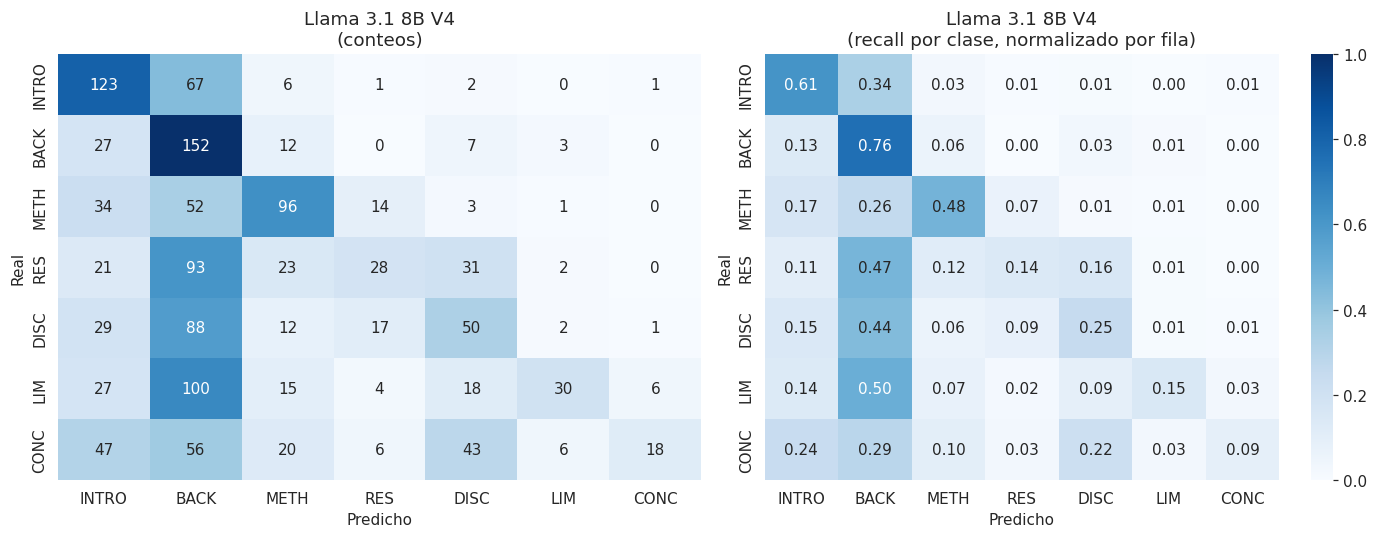

llama_accuracy,▁
llama_f1_macro,▁
llama_f1_micro,▁
llama_inference_time_minutes,▁
llama_unknown_predictions,▁
llama_accuracy,0.355
llama_f1_macro,0.32226
llama_f1_micro,0.35576
llama_inference_time_minutes,7.30292
llama_unknown_predictions,6


In [ ]:
llama_report = full_report(
    actuals, predictions,
    model_name=f'Llama 3.1 8B {VERSION.upper()} (few-shot 14ej, parser tolerante)',
    save_to=f'{RESULTS_DIR}/eval_llama_t1_{VERSION}.json',
)
plot_confusion_matrix(
    llama_report['confusion_matrix'], LABELS,
    title=f'Llama 3.1 8B {VERSION.upper()}',
    save_path=f'{PLOTS_DIR}/cm_llama_{VERSION}.png',
)
pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': actuals, 'predicted': predictions, 'raw_response': raw_responses,
}).to_csv(f'{RESULTS_DIR}/preds_llama_t1_{VERSION}.csv', index=False)

llama_run.log({
    "llama_accuracy": llama_report['accuracy'],
    "llama_f1_macro": llama_report['f1_macro'],
    "llama_f1_micro": llama_report['f1_micro'],
    "llama_f1_per_class": llama_report['f1_per_class'],
    "llama_inference_time_minutes": llama_inference_time / 60,
    "llama_unknown_predictions": llama_report['unknown_predictions'],
})

# Optional: Log confusion matrix image if you want to see it in W&B
# plt.figure(figsize=(10, 8))
# sns.heatmap(pd.DataFrame(llama_report['confusion_matrix'], index=LABELS, columns=LABELS), annot=True, fmt='d', cmap='Blues')
# plt.title(f'Llama 3.1 8B {VERSION.upper()} Confusion Matrix')
# llama_run.log({"Llama Confusion Matrix": wandb.Image(plt)})
# plt.close()

llama_run.finish()

In [ ]:
del llama_model
torch.cuda.empty_cache(); gc.collect()
if torch.cuda.is_available():
    free_gb = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
    print(f"VRAM libre: {free_gb:.1f} GB")

VRAM libre: 34.2 GB


## 9. GPT-4o-mini — zero-shot + few-shot

Igual que Llama: corremos ambos regímenes con la misma pipeline (`AsyncOpenAI`,
JSON mode, retry exponencial, concurrencia=8). El zero-shot omite
`FEW_SHOT_BLOCK` del system message.

### 9.1 GPT-4o-mini — zero-shot (sin few-shot block)

In [ ]:
@retry(
    stop=stop_after_attempt(MAX_RETRIES),
    wait=wait_exponential(multiplier=2, min=2, max=60),
    retry=retry_if_exception_type((RateLimitError, APIError, APITimeoutError)),
    reraise=True,
)
async def classify_one_zs(snippet: str) -> tuple[str, str]:
    resp = await client.chat.completions.create(
        model=GPT_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT +
                                          '\n\nResponde en formato JSON: {"category": "SIGLA"}'},
            {'role': 'user',   'content': f'Fragmento: "{snippet}"'},
        ],
        temperature=GPT_TEMPERATURE, max_tokens=GPT_MAX_TOKENS,
        response_format={'type': 'json_object'},
    )
    raw = resp.choices[0].message.content
    return parse_llm_label(raw), raw

async def classify_batch_zs(snippets):
    sem = asyncio.Semaphore(CONCURRENCY)
    async def bounded(s):
        async with sem:
            try: return await classify_one_zs(s)
            except Exception as e: return 'UNKNOWN', f'ERROR: {str(e)[:200]}'
    return await asyncio.gather(*[bounded(s) for s in snippets])

# Run con progreso
gpt_zs_preds, gpt_zs_raws, gpt_zs_actuals = [], [], []

t0 = time.time()
async def run_all_zs():
    results = []
    chunk = 200
    for i in range(0, len(snippets_to_classify), chunk):
        batch = snippets_to_classify[i:i+chunk]
        batch_results = await classify_batch_zs(batch)
        results.extend(batch_results)
        elapsed = time.time() - t0
        rate = (i + len(batch)) / elapsed
        print(f'  ZS  {i+len(batch):>4}/{len(snippets_to_classify)} · {elapsed/60:.1f} min · {rate:.1f} ex/s')
    return results

zs_results = await run_all_zs()
gpt_zs_preds  = [r[0] for r in zs_results]
gpt_zs_raws   = [r[1] for r in zs_results]
gpt_zs_actuals = test_df['category'].tolist()
gpt_zs_inference_time = time.time() - t0
print(f'\n✅ GPT ZS terminado en {gpt_zs_inference_time/60:.1f} min')

In [ ]:
gpt_zs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name=f"task1_gpt_zs_edwin_{VERSION}",
    tags=["llm", "zero-shot", "json-mode"],
    config={
        "model": GPT_MODEL,
        "temperature": GPT_TEMPERATURE,
        "max_tokens": GPT_MAX_TOKENS,
        "system_prompt_len": len(SYSTEM_PROMPT),
        "few_shot_examples": 0,
        "concurrency": CONCURRENCY,
        "max_retries": MAX_RETRIES,
        "regime": "zero-shot",
        "run_description": "GPT-4o-mini zero-shot evaluation (v3 notebook + v5 dataset)."
    }
)

gpt_zs_report = full_report(
    gpt_zs_actuals, gpt_zs_preds,
    model_name=f'{GPT_MODEL} {VERSION.upper()} (json_object, zero-shot, retry, conc={CONCURRENCY})',
    save_to=f'{RESULTS_DIR}/eval_gpt_zs_t1_{VERSION}.json',
)
plot_confusion_matrix(
    gpt_zs_report['confusion_matrix'], LABELS,
    title=f'{GPT_MODEL} {VERSION.upper()} (zero-shot)',
    save_path=f'{PLOTS_DIR}/cm_gpt_zs_{VERSION}.png',
)

# Estimación de costos ZS (system_prompt sin few-shot block)
total_prompt_tokens_zs = (sum(len(s.split())*1.3 for s in snippets_to_classify)
                          + len(SYSTEM_PROMPT)/4 * len(snippets_to_classify))
total_completion_tokens_zs = len(gpt_zs_preds) * GPT_MAX_TOKENS
cost_usd_zs = (total_prompt_tokens_zs * 0.15 + total_completion_tokens_zs * 0.60) / 1_000_000
print(f"\n💰 ZS ~Tokens: {total_prompt_tokens_zs:,.0f} prompt + {total_completion_tokens_zs:,.0f} completion = ~${cost_usd_zs:.3f}")

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': gpt_zs_actuals, 'predicted': gpt_zs_preds, 'raw_response': gpt_zs_raws,
}).to_csv(f'{RESULTS_DIR}/preds_gpt_zs_t1_{VERSION}.csv', index=False)

gpt_zs_run.log({
    "gpt_zs_accuracy": gpt_zs_report['accuracy'],
    "gpt_zs_f1_macro": gpt_zs_report['f1_macro'],
    "gpt_zs_f1_micro": gpt_zs_report['f1_micro'],
    "gpt_zs_f1_per_class": gpt_zs_report['f1_per_class'],
    "gpt_zs_inference_time_minutes": gpt_zs_inference_time / 60,
    "gpt_zs_unknown_predictions": gpt_zs_report['unknown_predictions'],
    "gpt_zs_cost_usd": cost_usd_zs,
})
gpt_zs_run.finish()

### 9.2 GPT-4o-mini — few-shot k=14 (baseline v2)

In [ ]:
from openai import AsyncOpenAI, RateLimitError, APIError, APITimeoutError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = AsyncOpenAI(api_key=OPENAI_API_KEY)

GPT_MODEL = 'gpt-4o-mini'
GPT_TEMPERATURE = 0.0
GPT_MAX_TOKENS = 16
CONCURRENCY = 8
MAX_RETRIES = 5

@retry(
    stop=stop_after_attempt(MAX_RETRIES),
    wait=wait_exponential(multiplier=2, min=2, max=60),
    retry=retry_if_exception_type((RateLimitError, APIError, APITimeoutError)),
    reraise=True,
)
async def classify_one(snippet: str) -> tuple[str, str]:
    resp = await client.chat.completions.create(
        model=GPT_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT + '\n\n' + FEW_SHOT_BLOCK +
                                          '\n\nResponde en formato JSON: {"category": "SIGLA"}'},
            {'role': 'user',   'content': f'Fragmento: "{snippet}"'},
        ],
        temperature=GPT_TEMPERATURE, max_tokens=GPT_MAX_TOKENS,
        response_format={'type': 'json_object'},
    )
    raw = resp.choices[0].message.content
    return parse_llm_label(raw), raw

async def classify_batch(snippets):
    sem = asyncio.Semaphore(CONCURRENCY)
    async def bounded(s):
        async with sem:
            try: return await classify_one(s)
            except Exception as e: return 'UNKNOWN', f'ERROR: {str(e)[:200]}'
    return await asyncio.gather(*[bounded(s) for s in snippets])

# Run con progreso
snippets_to_classify = test_df['neutralized_snippet'].tolist()
gpt_preds, gpt_raws, gpt_actuals = [], [], []
errors_irrecoverable = []

t0 = time.time()
async def run_all():
    results = []
    chunk = 200
    for i in range(0, len(snippets_to_classify), chunk):
        batch = snippets_to_classify[i:i+chunk]
        batch_results = await classify_batch(batch)
        results.extend(batch_results)
        elapsed = time.time() - t0
        rate = (i + len(batch)) / elapsed
        print(f"  {i+len(batch)}/{len(snippets_to_classify)} · {elapsed:.0f}s · {rate:.1f} req/s")
    return results

results = await run_all()
gpt_inference_time = time.time() - t0

for i, (pred, raw) in enumerate(results):
    gpt_preds.append(pred); gpt_raws.append(raw)
    gpt_actuals.append(test_df['category'].iloc[i])
    if raw.startswith('ERROR'): errors_irrecoverable.append((i, raw))

print(f"\n✅ GPT-4o-mini: {gpt_inference_time/60:.1f} min")
if errors_irrecoverable:
    print(f"⚠️  {len(errors_irrecoverable)} errores tras {MAX_RETRIES} reintentos")
    for idx, err in errors_irrecoverable[:3]:
        print(f"    [idx={idx}] {err[:140]}")

  200/1400 · 60s · 3.3 req/s
  400/1400 · 90s · 4.4 req/s
  600/1400 · 144s · 4.2 req/s
  800/1400 · 218s · 3.7 req/s
  1000/1400 · 258s · 3.9 req/s
  1200/1400 · 339s · 3.5 req/s
  1400/1400 · 419s · 3.3 req/s

✅ GPT-4o-mini: 7.0 min
⚠️  2 errores tras 5 reintentos
    [idx=432] ERROR: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-xMVTizrTFnlsR5VtfFSfWsdA on tokens pe
    [idx=1280] ERROR: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-xMVTizrTFnlsR5VtfFSfWsdA on tokens pe


In [ ]:
gpt_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_gpt_edwin_v2",
    tags=["llm", "json-mode"],
    config={
        "model": GPT_MODEL,
        "temperature": GPT_TEMPERATURE,
        "max_tokens": GPT_MAX_TOKENS,
        "system_prompt_len": len(SYSTEM_PROMPT),
        "few_shot_examples": len(_FEW_SHOT_RAW),
        "concurrency": CONCURRENCY,
        "max_retries": MAX_RETRIES,
        "run_description": "GPT-4o-mini few-shot evaluation with V4 refactored data."
    }
)

wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai



gpt-4o-mini V4 (json_object, few-shot, retry, conc=8)
Accuracy: 0.4457 | Macro F1: 0.4163 | Micro F1: 0.4460
UNKNOWN: 2/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.406     0.735     0.523       200
        BACK      0.421     0.731     0.535       201
        METH      0.626     0.595     0.610       200
         RES      0.413     0.320     0.361       200
        DISC      0.313     0.420     0.359       200
         LIM      0.872     0.205     0.332       200
        CONC      0.815     0.111     0.195       199

   micro avg      0.446     0.446     0.446      1400
   macro avg      0.552     0.445     0.416      1400
weighted avg      0.552     0.446     0.417      1400

Matriz de confusión (filas=real, cols=predicho):
       INTRO  BACK  METH  RES  DISC  LIM  CONC
INTRO    147    38    10    0     5    0     0
BACK      37   147     7    7     2    0     0
METH      46    15   119   12     6    1     0
RES       27    

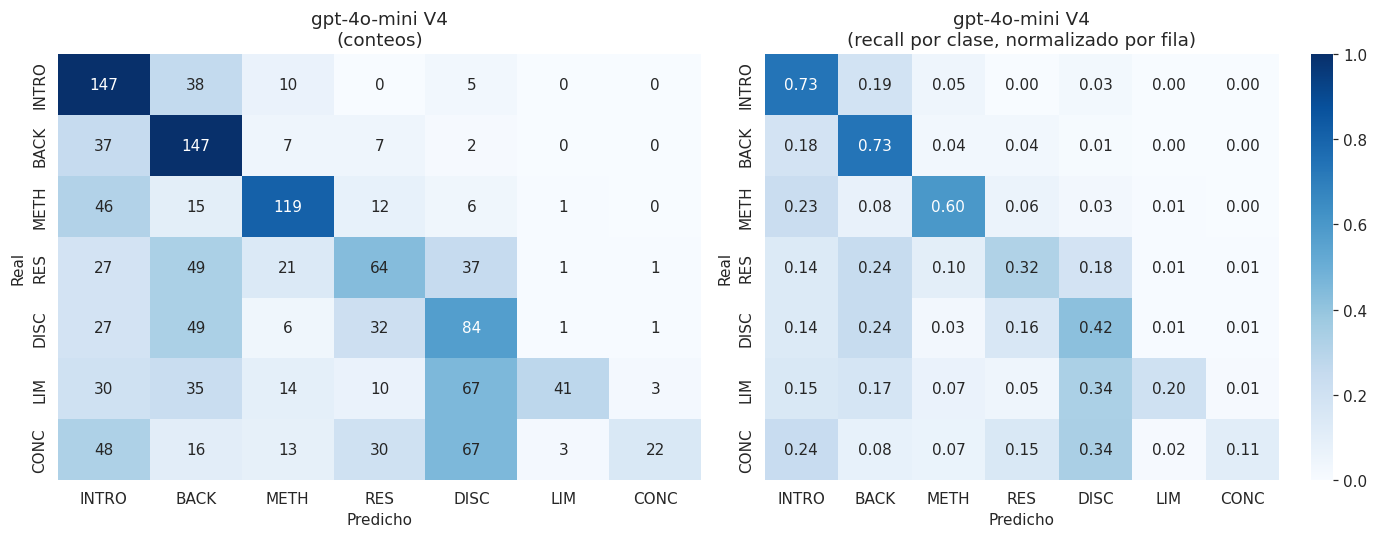


💰 ~Tokens estimados: 1,574,258 prompt + 22,400 completion = ~$0.250


gpt_accuracy,▁
gpt_cost_usd,▁
gpt_f1_macro,▁
gpt_f1_micro,▁
gpt_inference_time_minutes,▁
gpt_unknown_predictions,▁
gpt_accuracy,0.44571
gpt_cost_usd,0.24958
gpt_f1_macro,0.41631
gpt_f1_micro,0.44603
gpt_inference_time_minutes,6.98644


In [ ]:
gpt_report = full_report(
    gpt_actuals, gpt_preds,
    model_name=f'{GPT_MODEL} {VERSION.upper()} (json_object, few-shot, retry, conc={CONCURRENCY})',
    save_to=f'{RESULTS_DIR}/eval_gpt_t1_{VERSION}.json',
)
plot_confusion_matrix(
    gpt_report['confusion_matrix'], LABELS,
    title=f'{GPT_MODEL} {VERSION.upper()}',
    save_path=f'{PLOTS_DIR}/cm_gpt_{VERSION}.png',
)

# Estimación de costos
total_prompt_tokens = sum(len(s.split())*1.3 for s in snippets_to_classify) + len(SYSTEM_PROMPT + FEW_SHOT_BLOCK)/4 * len(snippets_to_classify)
total_completion_tokens = len(gpt_preds) * GPT_MAX_TOKENS
cost_usd = (total_prompt_tokens * 0.15 + total_completion_tokens * 0.60) / 1_000_000
print(f"\n💰 ~Tokens estimados: {total_prompt_tokens:,.0f} prompt + {total_completion_tokens:,.0f} completion = ~${cost_usd:.3f}")

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': gpt_actuals, 'predicted': gpt_preds, 'raw_response': gpt_raws,
}).to_csv(f'{RESULTS_DIR}/preds_gpt_t1_{VERSION}.csv', index=False)

gpt_run.log({
    "gpt_accuracy": gpt_report['accuracy'],
    "gpt_f1_macro": gpt_report['f1_macro'],
    "gpt_f1_micro": gpt_report['f1_micro'],
    "gpt_f1_per_class": gpt_report['f1_per_class'],
    "gpt_inference_time_minutes": gpt_inference_time / 60,
    "gpt_unknown_predictions": gpt_report['unknown_predictions'],
    "gpt_cost_usd": cost_usd,
})

gpt_run.finish()

## 10. Comparación final

In [ ]:
# Tabla comparativa V5: SciBETO (4 epochs) + Llama (ZS + FS) + GPT (ZS + FS)
comparison = pd.DataFrame([
    {'Modelo': f'SciBETO-large {VERSION.upper()} (FT, {EPOCHS} epochs, class weights)',
     'Regimen': 'fine-tuned',
     'Accuracy': scibeto_report['accuracy'], 'F1 Macro': scibeto_report['f1_macro'],
     'F1 Micro': scibeto_report['f1_micro'], 'UNKNOWN': scibeto_report['unknown_predictions'],
     'Tiempo (min)': round(scibeto_train_time / 60, 1),
     'Notas': f'{EPOCHS}ep, drop={DROPOUT}, lr={LR}'},
    {'Modelo': f'Llama 3.1 8B {VERSION.upper()} (zero-shot)',
     'Regimen': 'zero-shot',
     'Accuracy': llama_zs_report['accuracy'], 'F1 Macro': llama_zs_report['f1_macro'],
     'F1 Micro': llama_zs_report['f1_micro'], 'UNKNOWN': llama_zs_report['unknown_predictions'],
     'Tiempo (min)': round(llama_zs_inference_time / 60, 1),
     'Notas': f'4-bit, parser tolerante, trunc={truncation_count_zs}'},
    {'Modelo': f'Llama 3.1 8B {VERSION.upper()} (few-shot 14ej)',
     'Regimen': 'few-shot k=14',
     'Accuracy': llama_report['accuracy'], 'F1 Macro': llama_report['f1_macro'],
     'F1 Micro': llama_report['f1_micro'], 'UNKNOWN': llama_report['unknown_predictions'],
     'Tiempo (min)': round(llama_inference_time / 60, 1),
     'Notas': f'4-bit, parser tolerante, trunc={truncation_count}'},
    {'Modelo': f'{GPT_MODEL} {VERSION.upper()} (zero-shot)',
     'Regimen': 'zero-shot',
     'Accuracy': gpt_zs_report['accuracy'], 'F1 Macro': gpt_zs_report['f1_macro'],
     'F1 Micro': gpt_zs_report['f1_micro'], 'UNKNOWN': gpt_zs_report['unknown_predictions'],
     'Tiempo (min)': round(gpt_zs_inference_time / 60, 1),
     'Notas': f'API · ~${cost_usd_zs:.3f} · JSON mode · conc={CONCURRENCY}'},
    {'Modelo': f'{GPT_MODEL} {VERSION.upper()} (few-shot 14ej)',
     'Regimen': 'few-shot k=14',
     'Accuracy': gpt_report['accuracy'], 'F1 Macro': gpt_report['f1_macro'],
     'F1 Micro': gpt_report['f1_micro'], 'UNKNOWN': gpt_report['unknown_predictions'],
     'Tiempo (min)': round(gpt_inference_time / 60, 1),
     'Notas': f'API · ~${cost_usd:.3f} · JSON mode · conc={CONCURRENCY}'},
])
print(f'\n=== Comparación · Tarea 1 · {VERSION.upper()} (5 modelos) ===')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
comparison.to_csv(f'{RESULTS_DIR}/T1_comparison_final_{VERSION}.csv', index=False)

# Highlights
best = comparison.loc[comparison['F1 Macro'].idxmax()]
print(f'\n🏆 Mejor F1 Macro: {best["Modelo"]} = {best["F1 Macro"]:.4f}')

# Delta ZS → FS para cada LLM
delta_llama = llama_report['f1_macro'] - llama_zs_report['f1_macro']
delta_gpt   = gpt_report['f1_macro']   - gpt_zs_report['f1_macro']
print(f'\nDelta few-shot vs zero-shot:')
print(f'  Llama 3.1 8B:  ZS={llama_zs_report["f1_macro"]:.4f} → FS={llama_report["f1_macro"]:.4f} · Δ = {delta_llama:+.4f}')
print(f'  GPT-4o-mini:   ZS={gpt_zs_report["f1_macro"]:.4f} → FS={gpt_report["f1_macro"]:.4f} · Δ = {delta_gpt:+.4f}')

In [ ]:
# Bar chart F1 macro/micro por modelo (5 modelos)
fig, ax = plt.subplots(figsize=(13, 5))
models_short = [
    f'SciBETO {VERSION.upper()}',
    f'Llama 8B ZS',
    f'Llama 8B FS-14',
    f'GPT-4o-mini ZS',
    f'GPT-4o-mini FS-14',
]
reports = [scibeto_report, llama_zs_report, llama_report, gpt_zs_report, gpt_report]
f1_macros = [r['f1_macro'] for r in reports]
f1_micros = [r['f1_micro'] for r in reports]
x = np.arange(len(models_short)); w = 0.35
colors_macro = ['steelblue', 'orange', 'darkorange', 'crimson', 'darkred']
ax.bar(x - w/2, f1_macros, w, label='F1 Macro', color='steelblue')
ax.bar(x + w/2, f1_micros, w, label='F1 Micro', color='salmon')
ax.set_xticks(x); ax.set_xticklabels(models_short, rotation=20, ha='right')
ax.set_ylabel('F1'); ax.set_title(f'F1 por modelo · Tarea 1 · {VERSION.upper()}')
ax.set_ylim(0, max(max(f1_macros), max(f1_micros)) * 1.2)
for i, (m, c) in enumerate(zip(f1_macros, f1_micros)):
    ax.text(i - w/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, c + 0.01, f'{c:.3f}', ha='center', fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/f1_per_model_{VERSION}.png', bbox_inches='tight')
plt.show()

In [ ]:
# Grouped bar chart: F1 por clase × 5 modelos
fig, ax = plt.subplots(figsize=(15, 5.5))
x = np.arange(len(LABELS)); w = 0.16
ax.bar(x - 2*w, [scibeto_report['f1_per_class'][l]   for l in LABELS], w, label='SciBETO',          color='steelblue')
ax.bar(x - 1*w, [llama_zs_report['f1_per_class'][l]  for l in LABELS], w, label='Llama ZS',         color='gold')
ax.bar(x,       [llama_report['f1_per_class'][l]     for l in LABELS], w, label='Llama FS-14',      color='orange')
ax.bar(x + 1*w, [gpt_zs_report['f1_per_class'][l]    for l in LABELS], w, label='GPT-4o-mini ZS',   color='lightcoral')
ax.bar(x + 2*w, [gpt_report['f1_per_class'][l]       for l in LABELS], w, label='GPT-4o-mini FS-14',color='crimson')
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylabel('F1 por clase'); ax.set_title(f'F1 por clase × modelo · {VERSION.upper()}')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/f1_per_class_{VERSION}.png', bbox_inches='tight')
plt.show()

V3 reports encontrados: ['SciBETO', 'Llama', 'GPT']

 Modelo  V3 F1 Macro  V4 F1 Macro       Δ  V3 Accuracy  V4 Accuracy
SciBETO       0.3641       0.3498 -0.0144       0.3647       0.3536
  Llama       0.2435       0.3223  0.0788       0.2898       0.3550
    GPT       0.0495       0.4163  0.3668       0.0264       0.4457


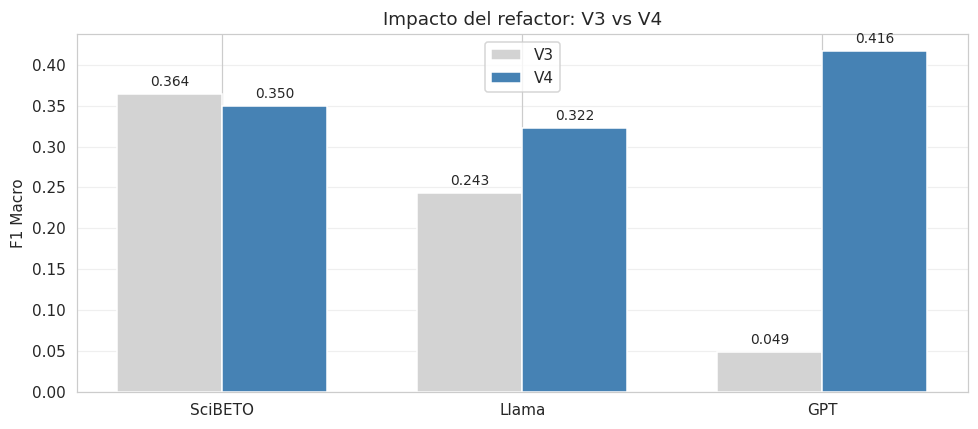

In [ ]:
# Comparativa  si los reportes previos existen
v3_paths = {
    'SciBETO': f'{RESULTS_DIR}/eval_scibeto_t1.json',
    'Llama':   f'{RESULTS_DIR}/eval_llama_t1.json',
    'GPT':     f'{RESULTS_DIR}/eval_gpt_t1.json',
}
v4_reports = {'SciBETO': scibeto_report, 'Llama': llama_report, 'GPT': gpt_report}

v3_loaded = {}
for k, p in v3_paths.items():
    if os.path.exists(p):
        with open(p) as f: v3_loaded[k] = json.load(f)

if v3_loaded:
    print(f"V3 reports encontrados: {list(v3_loaded.keys())}\n")
    rows = []
    for k in ['SciBETO','Llama','GPT']:
        v3 = v3_loaded.get(k, {})
        v4 = v4_reports[k]
        rows.append({
            'Modelo':       k,
            'V3 F1 Macro':  v3.get('f1_macro', np.nan),
            'V4 F1 Macro':  v4['f1_macro'],
            'Δ':            v4['f1_macro'] - v3.get('f1_macro', np.nan),
            'V3 Accuracy':  v3.get('accuracy', np.nan),
            'V4 Accuracy':  v4['accuracy'],
        })
    delta_df = pd.DataFrame(rows).round(4)
    print(delta_df.to_string(index=False))
    delta_df.to_csv(f'{RESULTS_DIR}/T1_v3_vs_v4_delta.csv', index=False)

    # Bar chart comparativo V3 vs V4
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(rows)); w = 0.35
    v3_vals = [r['V3 F1 Macro'] for r in rows]
    v4_vals = [r['V4 F1 Macro'] for r in rows]
    ax.bar(x - w/2, v3_vals, w, label='V3', color='lightgray')
    ax.bar(x + w/2, v4_vals, w, label='V4', color='steelblue')
    ax.set_xticks(x); ax.set_xticklabels([r['Modelo'] for r in rows])
    ax.set_ylabel('F1 Macro'); ax.set_title('Impacto del refactor: V3 vs V4')
    for i, (a, b) in enumerate(zip(v3_vals, v4_vals)):
        if not np.isnan(a): ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
        ax.text(i + w/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/v3_vs_v4_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron reportes V3 en disco. La comparativa V3↔V4 se omite.")

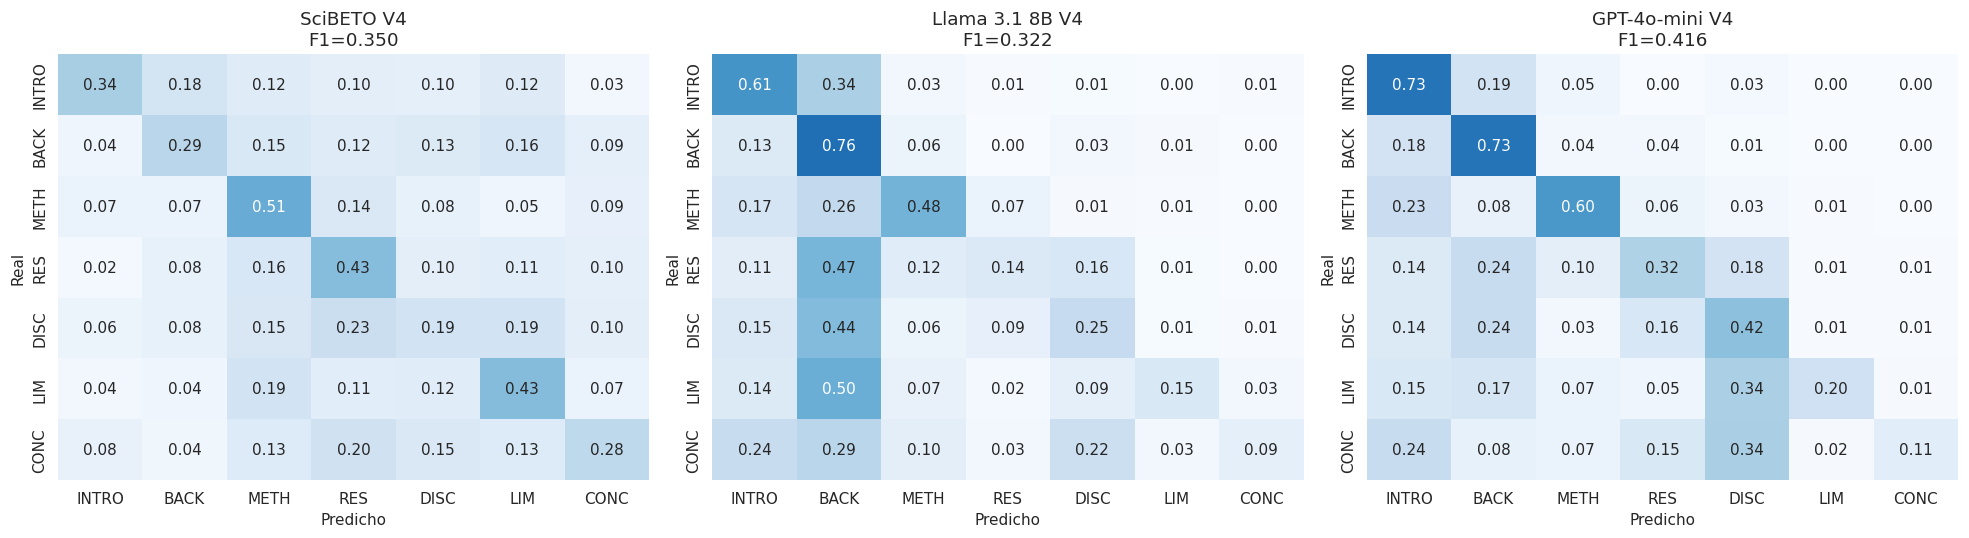

In [ ]:
# Side-by-side de matrices de confusión (los 3 modelos V4)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, rep) in zip(axes, [('SciBETO V4', scibeto_report),
                                    ('Llama 3.1 8B V4', llama_report),
                                    ('GPT-4o-mini V4', gpt_report)]):
    cm = np.array(rep['confusion_matrix'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False,
                vmin=0, vmax=1)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(f'{name}\nF1={rep["f1_macro"]:.3f}')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/cm_side_by_side_{VERSION}.png', bbox_inches='tight')
plt.show()

## 11. Marco metodológico — material para el reporte

Esta sección documenta la decisión metodológica que llevó a V4, redactada para integrarse al reporte académico del proyecto. Cubre cuatro puntos: problema, evidencia, intervención, y contribución.

### 11.1 El problema: incompatibilidad estructural train/test

Construimos el dataset de entrenamiento para la tarea T1 (clasificación retórica en 7 clases) mediante un extractor regex aplicado sobre 1.8 millones de documentos del corpus CORE. El extractor selecciona, por cada documento, ventanas de ~750 palabras centradas en ocurrencias de keywords retóricos (`metodología`, `resultados`, etc.) y aplica una máscara `[MASK]` sobre dichos keywords para forzar al modelo a aprender de la semántica circundante y no de los encabezados.

El conjunto de prueba (gold), por otra parte, fue construido mediante anotación manual de 1 401 fragmentos balanceados (200 por clase), con un enmascaramiento independiente que reemplaza palabras de contenido temático específicas de cada fragmento (no del listado global de keywords retóricos).

Los modelos entrenados sobre este dataset exhibieron una brecha grande y persistente entre validación y test:

| Modelo (V3) | F1 macro VAL | F1 macro TEST | Δ |
|-------------|--------------|---------------|---|
| SciBETO-large fine-tuned | 0.62 | 0.32 | −0.30 |
| GPT-4o-mini zero-shot    | —    | 0.38 | — |
| Llama 3.1 8B few-shot    | —    | 0.27 | — |

Esto motivó una auditoría del pipeline de datos.

### 11.2 La evidencia: análisis exploratorio comparativo

Definimos seis ejes de análisis comparativo entre train, val y test:

1. **Distribución de longitud** (chars, palabras, tokens BPE) por clase y global
2. **Comportamiento de la máscara** (frecuencia, keywords residuales, simetría)
3. **Divergencia de vocabulario** por clase con Jensen-Shannon
4. **Marcadores estilísticos** (citas, p-values, hedges, conectores conclusivos, marcadores de discusión) normalizados por extensión
5. **Análisis de errores cruzado** SciBETO vs GPT
6. **Metadatos del extractor** (regex_score, matched_keywords) — eje que no había sido analizado en versiones previas

Los hallazgos consistentes:

- **Distribución de longitud disjunta**: train mediana 761 palabras (σ=109, ventana casi fija); test mediana 243 palabras (σ=342, alta variabilidad). En las clases DISC y LIM, el test tiene mediana 60–66 palabras, un orden de magnitud más corto que train.
- **Estrategias de máscara incompatibles**: solo el 4.4 % de los `matched_keywords` del test pertenecen al listado SOFT_MASK del notebook, vs 26 % en train. El test enmascara contenido temático (`devops`, `software`, `lesión`); train enmascara cues retóricos.
- **Contaminación del train con frontmatter académico**: 18 % de filas de train contienen patrones inequívocos de portadas de tesis (`ORCID`, `dedicatoria`, `agradecimiento`, `jurado`, `amor incondicional`). Las clases INTRO y METH muestran 34 % de contaminación. En test, este porcentaje es del 0.1 %.
- **Modelo aprende señales espurias**: los tokens más sobre-representados en train|METH son *agradecimiento, dedicatoria, dios, jurado, amor* — léxico inequívoco de dedicatorias y portadas de tesis, no de descripciones metodológicas.

### 11.3 La intervención: refactor del train (V4)

Aplicamos tres correcciones sobre `dataset_train.csv` y `dataset_val.csv`, dejando el test intacto:

1. **Filtro de frontmatter**: 12 patrones regex sobre el primer 30 % del texto. Drop si el score ≥ 2.
2. **Truncación centrada en anchor**: ventana de 240w ± 160 (jitter) centrada en el primer `matched_keyword`. Para fragmentos ya cortos, conservación íntegra.
3. **Máscara simétrica**: aplicación de `apply_soft_mask` con el mismo listado SOFT_MASK a TRAIN, VAL y TEST. Restituye la simetría que la corrección V3 había roto.

Calibración del filtro: el umbral de score=2 conserva 82 % del train (8 770 / 10 694 filas) y descarta solo 0.1 % del test (2 / 1 400), lo que valida la especificidad del detector — el filtro identifica contaminación real, no señal útil.

### 11.4 La contribución académica

Independientemente del impacto cuantitativo del refactor (que se reporta en la sección 10), el ejercicio produce una contribución metodológica replicable:

1. **Diagnóstico**: un protocolo de seis ejes de EDA comparativo entre conjuntos de entrenamiento y evaluación, aplicable a cualquier proyecto que combine extracción automática a gran escala con evaluación humana cuidadosa. Este tipo de mismatch es probable que ocurra silenciosamente en otros proyectos de NLP en español académico, donde los corpora abiertos (CORE, SciELO) se acoplan con conjuntos de prueba pequeños y anotados ad hoc.

2. **Hallazgo empírico**: en español, sobre datos con shift distribucional moderado, un LLM grande zero-shot (GPT-4o-mini, F1=0.38) puede superar a un modelo bidireccional especializado fine-tuneado (SciBETO-large, F1=0.32), no porque el LLM sea mejor en la tarea, sino porque el dataset de entrenamiento del modelo especializado no representa al dominio de evaluación. Esto invierte la intuición común de que el fine-tuning siempre vence al zero-shot.

3. **Lección de diseño**: cuando se diseña una pipeline en producción que mezcla un modelo fine-tuned con uno zero-shot (como nuestro demostrador FastAPI), la decisión de cuál exponer al usuario no debe basarse en F1 global, sino en F1 condicional al régimen de longitud y dominio del input recibido. Los usuarios envían fragmentos cortos como los del test gold — no ventanas de 750 palabras.

### 11.5 Limitaciones y trabajo futuro

- El refactor no resuelve la incompatibilidad de fondo entre los dos pipelines de construcción del dataset. Reduce el shift en longitud y máscara, pero no aborda la diferencia de fuente (CORE filtrado vs anotación manual de muestras balanceadas).
- Un trabajo futuro debería re-anotar manualmente una muestra del corpus CORE con la misma metodología que se usó para construir el test gold, para producir un dataset coherente de extremo a extremo. Alternativamente, usar el modelo más fuerte (GPT-4o-mini) como anotador silver para generar un nuevo conjunto de entrenamiento alineado con el test.
- La hipótesis "T2 (clasificación binaria de contribuciones) funciona porque tiene menor sensibilidad a este tipo de shift" debería verificarse aplicando el mismo protocolo de EDA al pipeline de T2.